In [1]:
from google.colab import files

uploaded = files.upload()

Saving seattle-weather.csv to seattle-weather.csv


Mean Absolute Error: 2.02
Root Mean Squared Error: 2.61
R2 Score: 0.88


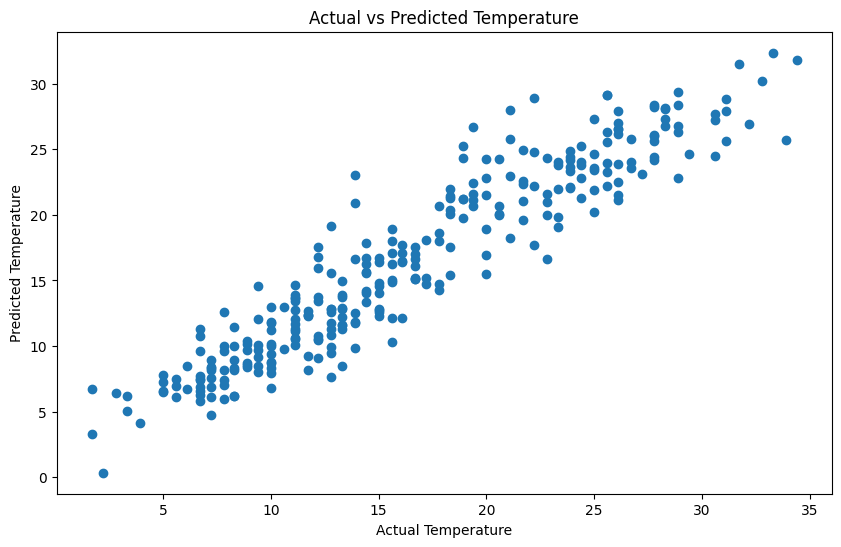

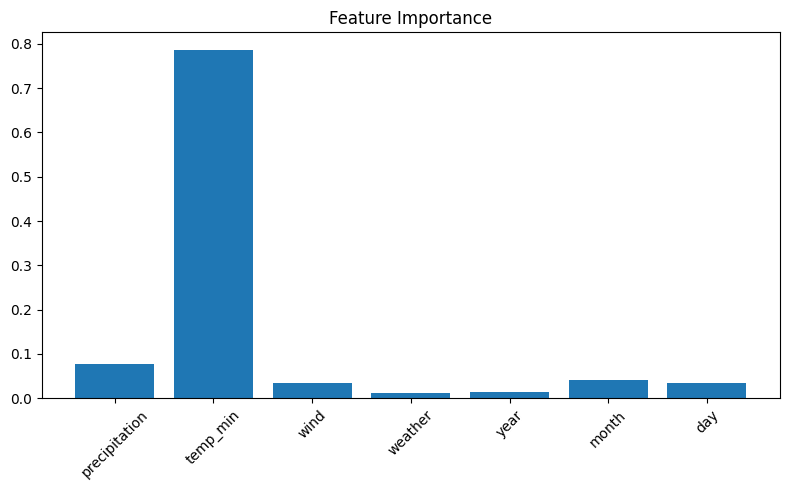


Predicted Maximum Temperature: 23.69 °C


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("seattle-weather.csv")

df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
le = LabelEncoder()
df['weather'] = le.fit_transform(df['weather'])
X = df[['precipitation', 'temp_min', 'wind', 'weather',
        'year', 'month', 'day']]

y = df['temp_max']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R2 Score:", round(r2, 2))
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()
new_data = pd.DataFrame({
    'precipitation': [0.0],
    'temp_min': [12.0],
    'wind': [3.5],
    'weather': [le.transform(['sun'])[0]],
    'year': [2016],
    'month': [6],
    'day': [15]
})

prediction = model.predict(new_data)

print("\nPredicted Maximum Temperature:", round(prediction[0], 2), "°C")